# 06 - Surrogate Model Comparison: Black-box vs Additive Corrective Hybrid

This notebook compares two surrogate strategies that use the same input features \(x\) but different prediction pipelines:

- **Black-box (`stageBase`)**: purely data-driven mapping from \(x\) to \(J(t)\)
- **Additive corrective hybrid (`stageCorrected`)**: starts from `stageBase` and applies a bounded learned correction
- **Final deployed stage (`stageFinal`)**: validation-selected blend to avoid harming baseline performance

Both models are pre-trained and loaded from `results/ml/final/`.


In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skin_diffusion.notebook_helpers import setup_repo_root

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

run_root = Path('results/ml/final')
required_seeds = [42, 123, 7]
primary_seed = 42

bb_dir = run_root / 'blackbox_ridge'
if not bb_dir.exists():
    raise FileNotFoundError(f'Missing blackbox output directory: {bb_dir}')

corr_run_dirs = {seed: run_root / f'corrective_ridge_seed{seed}' for seed in required_seeds}
missing = [seed for seed, d in corr_run_dirs.items() if not d.exists()]
if missing:
    raise FileNotFoundError(
        f'Missing corrective result directories under {run_root}: {missing}'
    )

seed_order = required_seeds

# -- Load all pre-computed results --
bb = json.load(open(bb_dir / 'metrics_test.json'))
bb_summary = json.load(open(bb_dir / 'summary.json'))
bb_runtime = json.load(open(bb_dir / 'runtime.json'))
bb_pred = np.load(bb_dir / 'pred_test.npz')

corr_seeds = {}
for seed in seed_order:
    d = corr_run_dirs[seed]
    corr_seeds[seed] = {
        'metrics': json.load(open(d / 'metrics_test.json')),
        'summary': json.load(open(d / 'summary.json')),
        'history': json.load(open(d / 'history.json')),
    }

corr_pred = np.load(corr_run_dirs[primary_seed] / 'pred_test.npz')

print(f'Black-box test predictions: {bb_pred["j_true"].shape}')
print(f'Corrective test predictions: {corr_pred["j_true"].shape}')
print(f'Corrective seeds loaded (report): {seed_order}')
print(f'Primary seed for plots: {primary_seed}')


Black-box test predictions: (150, 1441)
Corrective test predictions: (150, 1441)
Corrective seeds loaded (report): [42, 123, 7]
Primary seed for plots: 42


### Black-box surrogate: simple view

Black-box is the baseline model that maps input features to a full flux curve.

What it does (high level):
- standardise features
- compress curves into a small PCA representation
- use Ridge to predict that compact representation
- reconstruct the full curve and clip to non-negative values

Why this helps:
- PCA reduces output complexity
- Ridge is stable and fast
- gives a strong baseline before any correction

In short: this stage is a clean data-driven predictor of $J(t)$.


### Additive corrective hybrid model

The hybrid starts from the black-box prediction and adds a bounded correction.

Core idea (one line):
$$
J_{\mathrm{corr}} = J_{\mathrm{base}} + \text{bounded correction}
$$

Practical meaning:
- correction size is limited so updates stay controlled
- correction is larger where base flux is larger
- optional learned gate decides per run how much correction to trust

In short: it is mostly a safe adjustment layer on top of the baseline, not a completely separate model family.


### Training losses used in final runs

Only a small set of practical losses is used here:
- **flux fit:** match predicted vs true flux curves
- **anchor:** avoid unnecessary drift from baseline early in training
- **non-negativity:** discourage negative flux
- **peak guidance:** improve peak value and peak timing
- **gate regularisation:** avoid unstable all-or-nothing gating early

In short: the objective balances better fit with stable, sensible corrections.


### No-harm validation blend

After training, the model does not automatically apply full correction.

Instead it blends baseline and corrected predictions:
$$
J_{\mathrm{final}} = J_{\mathrm{base}} + \lambda\,(J_{\mathrm{corr}} - J_{\mathrm{base}}), \; \lambda\in[0,1]
$$

How \(\lambda\) is chosen:
- test a small grid on validation data
- pick the value with best validation relative $L_2$

Why this matters:
- prevents correction from hurting a strong baseline
- keeps deployment behaviour conservative and robust


## 1 - Additive corrective surrogate training convergence

The corrective hybrid is trained with the final objective,
and we plot loss components and validation $L_2$ across report seeds.


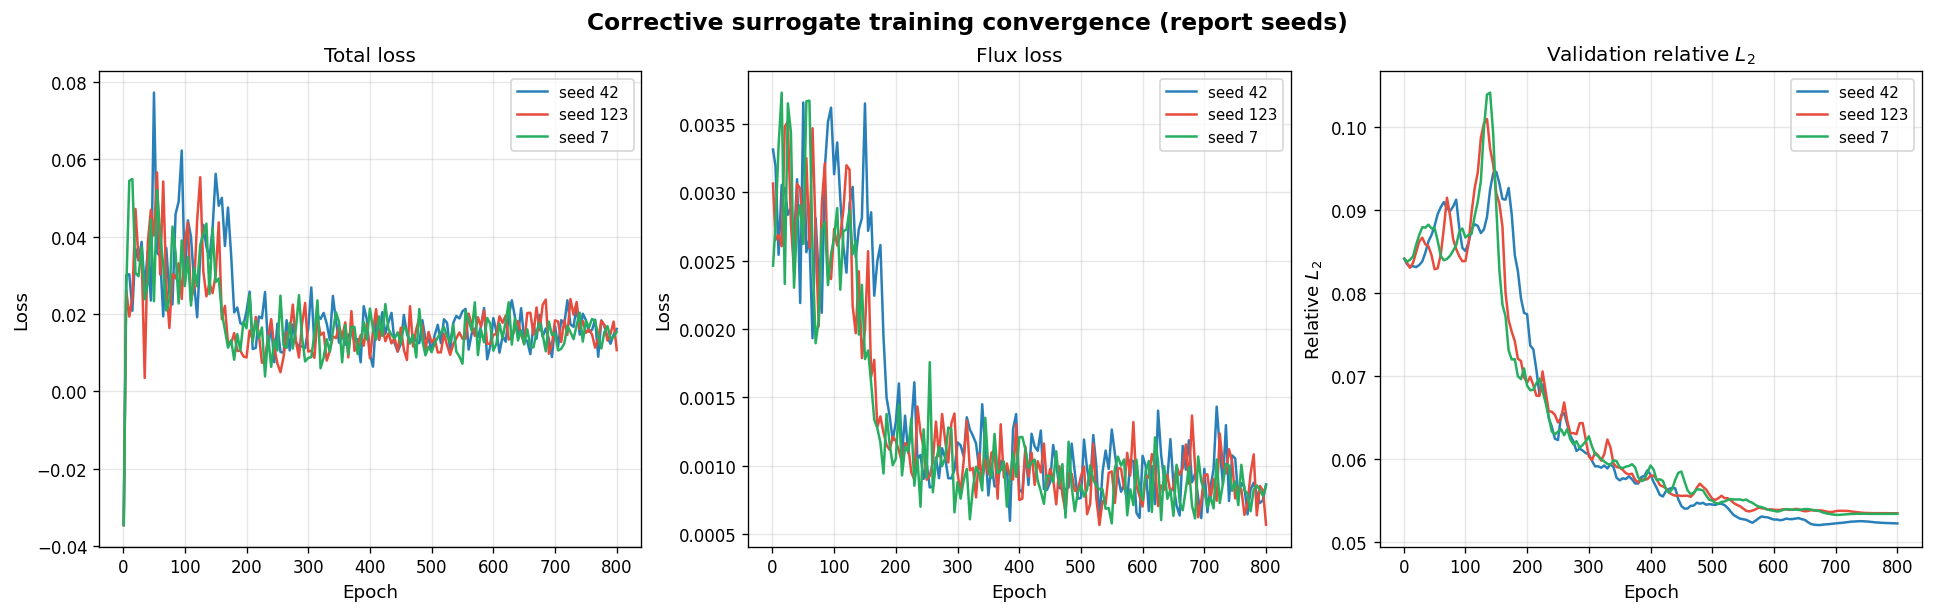

In [13]:
base_palette = ['#2980b9', '#e74c3c', '#27ae60', '#8e44ad', '#f39c12']
seed_colours = {seed: base_palette[i % len(base_palette)] for i, seed in enumerate(seed_order)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Corrective surrogate training convergence (report seeds)', fontsize=14, fontweight='bold')

for seed, c in seed_colours.items():
    hist = corr_seeds[seed]['history']
    epochs = [h['epoch'] for h in hist]
    total_loss = [h['loss_total'] for h in hist]
    flux_loss = [h['loss_flux'] for h in hist]
    val_l2 = [h['val_rel_l2'] for h in hist]

    axes[0].plot(epochs, total_loss, lw=1.5, color=c, label=f'seed {seed}')
    axes[1].plot(epochs, flux_loss, lw=1.5, color=c, label=f'seed {seed}')
    axes[2].plot(epochs, val_l2, lw=1.5, color=c, label=f'seed {seed}')

for ax, title, ylabel in zip(axes,
    ['Total loss', 'Flux loss', 'Validation relative $L_2$'],
    ['Loss', 'Loss', 'Relative $L_2$']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.show()


**Breakdown.**

- Convergence is assessed across all seeds, not a single run.
- The key check is stable loss reduction with no late-stage divergence and consistent validation behaviour.
- If one seed diverges strongly, conclusions should be reported with caution.


## 2 - Curve-level accuracy

Comparing predicted vs true flux curves on the **held-out test set** (150 runs).
We show 6 representative examples -- 3 each for black-box and corrective surrogate.


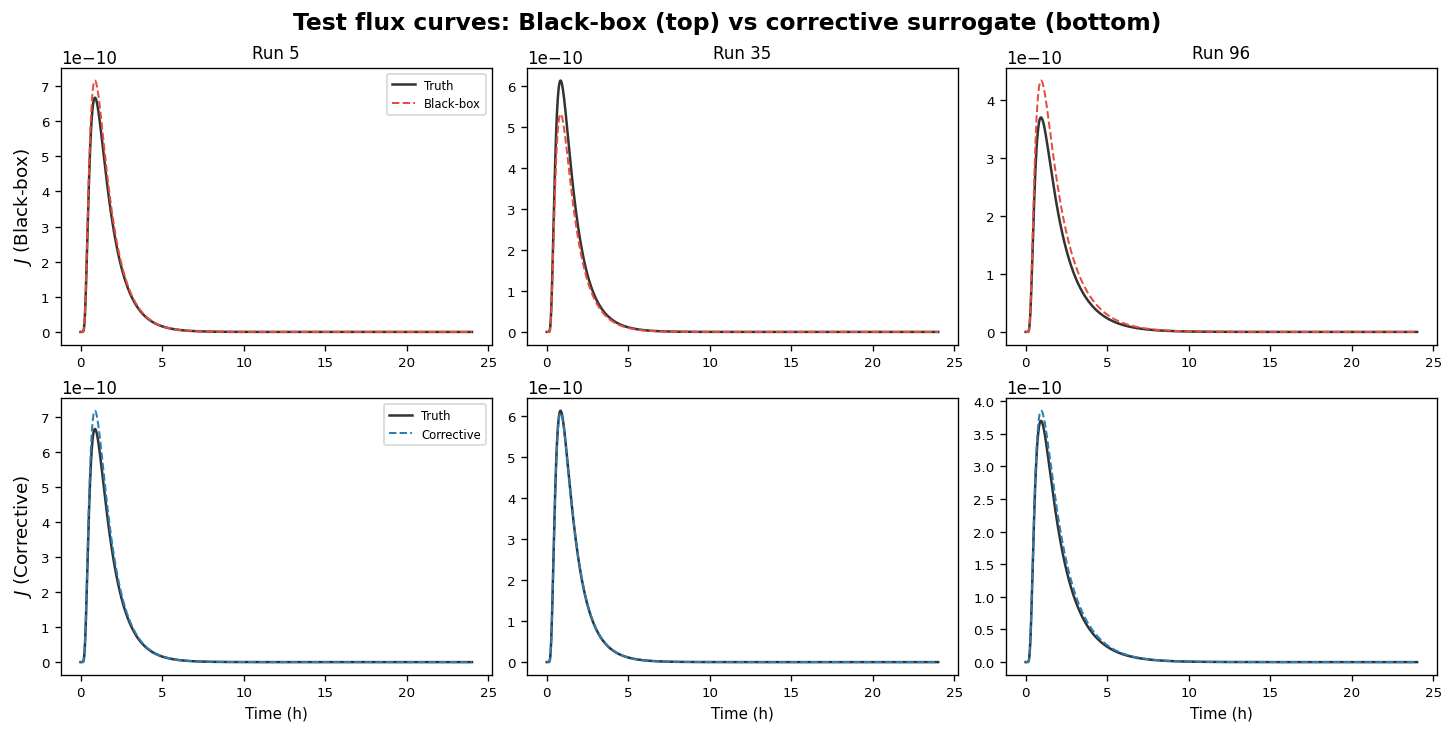

In [14]:
rng = np.random.default_rng(200)
n_test = bb_pred['j_true'].shape[0]
sample_idxs = sorted(rng.choice(n_test, size=3, replace=False))

fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
fig.suptitle('Test flux curves: Black-box (top) vs corrective surrogate (bottom)', fontsize=14, fontweight='bold')

for col, idx in enumerate(sample_idxs):
    t_h = bb_pred['t'][idx] / 3600.0
    j_true = bb_pred['j_true'][idx]

    # Black-box
    ax = axes[0, col]
    ax.plot(t_h, j_true, 'k-', lw=1.5, label='Truth', alpha=0.8)
    ax.plot(t_h, bb_pred['j_stageFinal'][idx], '--', color='#e74c3c',
            lw=1.2, label='Black-box')
    ax.set_title(f'Run {idx}', fontsize=10)
    if col == 0:
        ax.set_ylabel('$J$ (Black-box)')
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.legend(fontsize=7)

    # Corrective surrogate
    ax = axes[1, col]
    ax.plot(t_h, j_true, 'k-', lw=1.5, label='Truth', alpha=0.8)
    ax.plot(t_h, corr_pred['j_stageFinal'][idx], '--', color='#2980b9',
            lw=1.2, label='Corrective')
    ax.set_xlabel('Time (h)', fontsize=9)
    if col == 0:
        ax.set_ylabel('$J$ (Corrective)')
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.legend(fontsize=7)

plt.show()

**Breakdown.**

- These examples are qualitative sanity checks to complement aggregate metrics.
- Focus on early transient fit, peak timing, and tail behaviour, since different models can fail in different regions.
- Final claims should still come from full-test metrics, not a few hand-picked curves.


## 3 - Curve error over time

Mean absolute error across all 150 test curves at each time step.

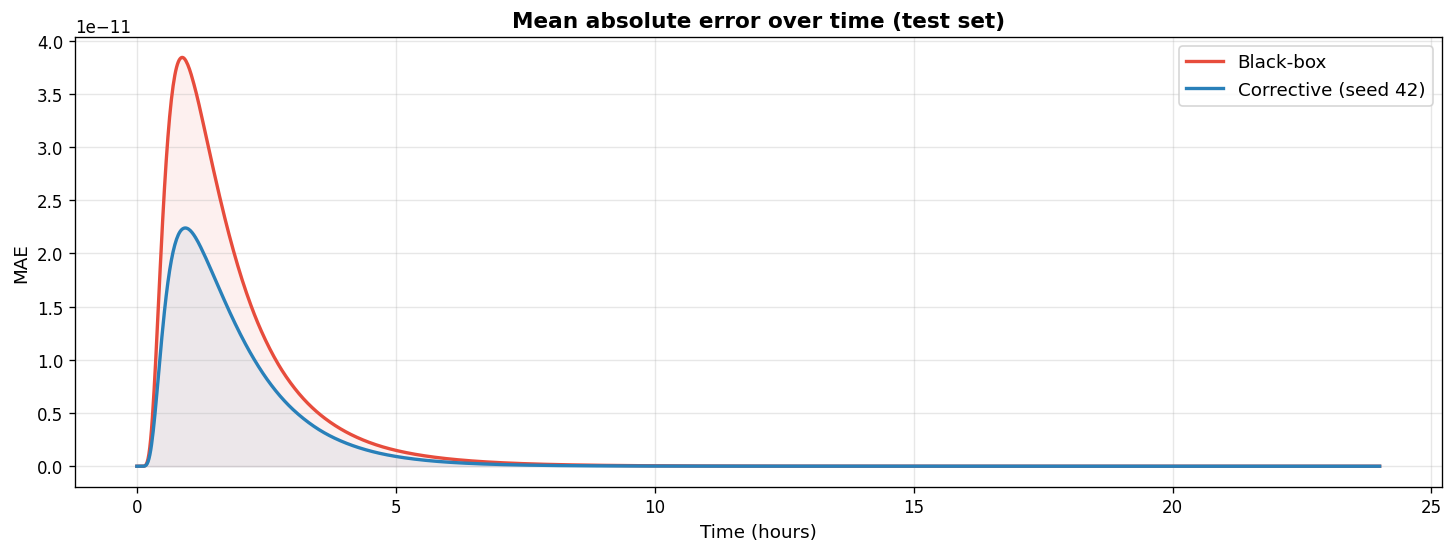

In [15]:
t_h = bb_pred['t'][0] / 3600.0

bb_mae_t = np.mean(np.abs(bb_pred['j_stageFinal'] - bb_pred['j_true']), axis=0)
corr_mae_t = np.mean(np.abs(corr_pred['j_stageFinal'] - corr_pred['j_true']), axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(t_h, bb_mae_t, lw=2, color='#e74c3c', label='Black-box')
ax.plot(t_h, corr_mae_t, lw=2, color='#2980b9', label='Corrective (seed 42)')
ax.fill_between(t_h, 0, bb_mae_t, alpha=0.08, color='#e74c3c')
ax.fill_between(t_h, 0, corr_mae_t, alpha=0.08, color='#2980b9')

ax.set_title('Mean absolute error over time (test set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('MAE')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

**Breakdown.**

- Time-resolved MAE shows where each model gains or loses accuracy during the delivery window.
- This helps avoid over-relying on one scalar metric when errors are phase-specific.
- For transdermal flux, early-time and around-peak windows are usually most informative.


## 4 - Per-run error distribution (CDF)

The empirical CDF of per-curve relative $L_2$ error shows what fraction of test curves
are predicted within a given accuracy.

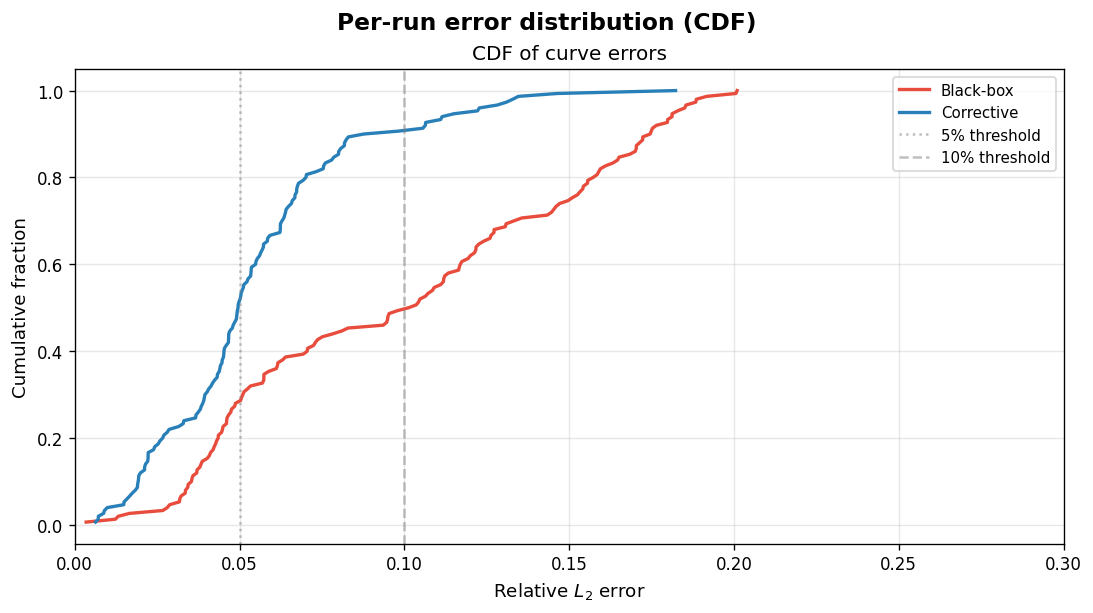

Black-box: median=0.1024, p90=0.1746, max=0.2010
Corrective: median=0.0496, p90=0.0888, max=0.1823


In [16]:
def relative_l2_per_run(j_pred, j_true):
    diff = j_pred - j_true
    num = np.sqrt(np.mean(diff ** 2, axis=1))
    den = np.sqrt(np.mean(j_true ** 2, axis=1))
    return num / np.maximum(den, 1e-30)

bb_rl2 = relative_l2_per_run(bb_pred['j_stageFinal'], bb_pred['j_true'])
corr_rl2 = relative_l2_per_run(corr_pred['j_stageFinal'], corr_pred['j_true'])

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
fig.suptitle('Per-run error distribution (CDF)', fontsize=14, fontweight='bold')

for data, label, c in [
    (bb_rl2, 'Black-box', '#e74c3c'),
    (corr_rl2, 'Corrective', '#2980b9'),
]:
    sorted_d = np.sort(data)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax.plot(sorted_d, cdf, lw=2, color=c, label=label)

ax.axvline(0.05, ls=':', color='grey', alpha=0.5, label='5% threshold')
ax.axvline(0.10, ls='--', color='grey', alpha=0.5, label='10% threshold')
ax.set_xlabel('Relative $L_2$ error')
ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of curve errors')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 0.3)

plt.show()

# Summary stats
for name, data in [('Black-box', bb_rl2), ('Corrective', corr_rl2)]:
    print(f'{name}: median={np.median(data):.4f}, p90={np.percentile(data, 90):.4f}, '
          f'max={np.max(data):.4f}')

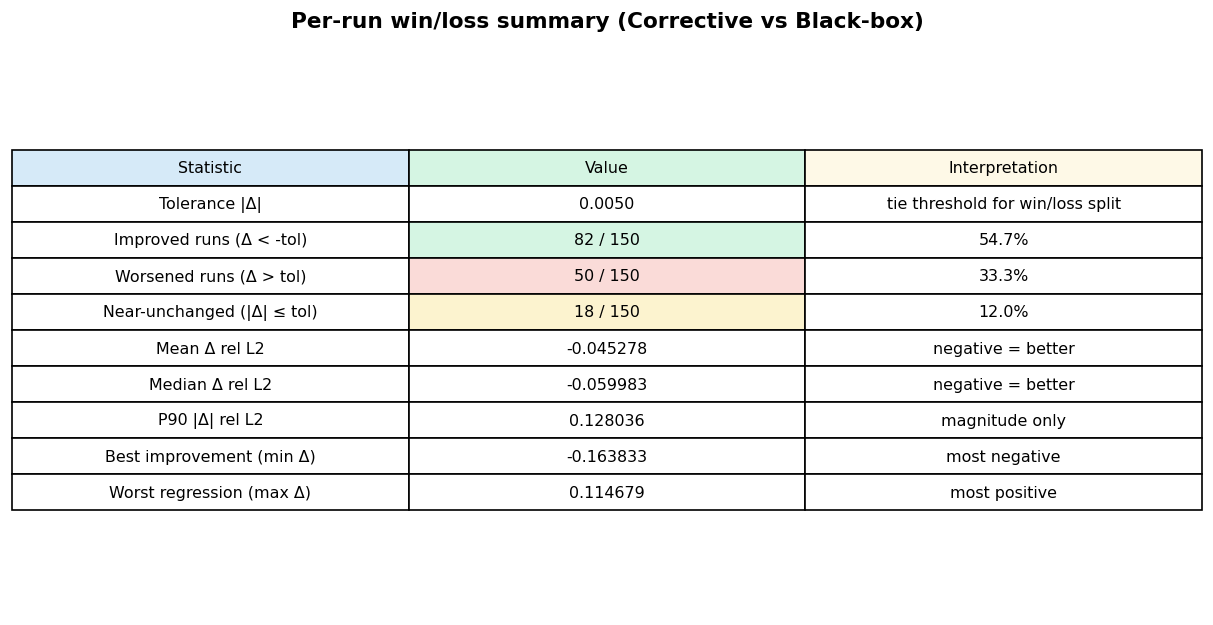

In [17]:
# Win/loss direction summary table (Corrective vs Black-box)
delta_rl2 = corr_rl2 - bb_rl2  # negative means corrective improved that run

# Use a practical tolerance so tiny near-zero deltas are treated as ties.
# Chosen from observed near-zero pile-up in the delta distribution.
tol = 5e-3

n = len(delta_rl2)
n_improved = int(np.sum(delta_rl2 < -tol))
n_worsened = int(np.sum(delta_rl2 > tol))
n_neutral = int(np.sum(np.abs(delta_rl2) <= tol))

rows = [
    ['Tolerance |Δ|', f'{tol:.4f}', 'tie threshold for win/loss split'],
    ['Improved runs (Δ < -tol)', f'{n_improved} / {n}', f'{100.0 * n_improved / n:.1f}%'],
    ['Worsened runs (Δ > tol)', f'{n_worsened} / {n}', f'{100.0 * n_worsened / n:.1f}%'],
    ['Near-unchanged (|Δ| ≤ tol)', f'{n_neutral} / {n}', f'{100.0 * n_neutral / n:.1f}%'],
    ['Mean Δ rel L2', f'{np.mean(delta_rl2):.6f}', 'negative = better'],
    ['Median Δ rel L2', f'{np.median(delta_rl2):.6f}', 'negative = better'],
    ['P90 |Δ| rel L2', f'{np.percentile(np.abs(delta_rl2), 90):.6f}', 'magnitude only'],
    ['Best improvement (min Δ)', f'{np.min(delta_rl2):.6f}', 'most negative'],
    ['Worst regression (max Δ)', f'{np.max(delta_rl2):.6f}', 'most positive'],
]

fig, ax = plt.subplots(figsize=(10, 5.1), constrained_layout=True)
ax.axis('off')
table = ax.table(
    cellText=rows,
    colLabels=['Statistic', 'Value', 'Interpretation'],
    cellLoc='center',
    loc='center',
    colColours=['#d6eaf8', '#d5f5e3', '#fef9e7'],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.0, 1.5)

for i, row in enumerate(rows, start=1):
    if row[0].startswith('Improved'):
        table[i, 1].set_facecolor('#d5f5e3')
    elif row[0].startswith('Worsened'):
        table[i, 1].set_facecolor('#fadbd8')
    elif row[0].startswith('Near-unchanged'):
        table[i, 1].set_facecolor('#fcf3cf')

ax.set_title('Per-run win/loss summary (Corrective vs Black-box)', fontsize=13, fontweight='bold', pad=12)
plt.show()

**Breakdown.**

- The CDF gives a robust distribution-level comparison without binning sensitivity.
- Curves shifted left indicate lower error at the same coverage level.
- The table below reports per-run win/loss direction and delta statistics to complement the CDF.


## 5 - Scalar target accuracy

Parity plots (predicted vs true) for each of the five scalar targets.

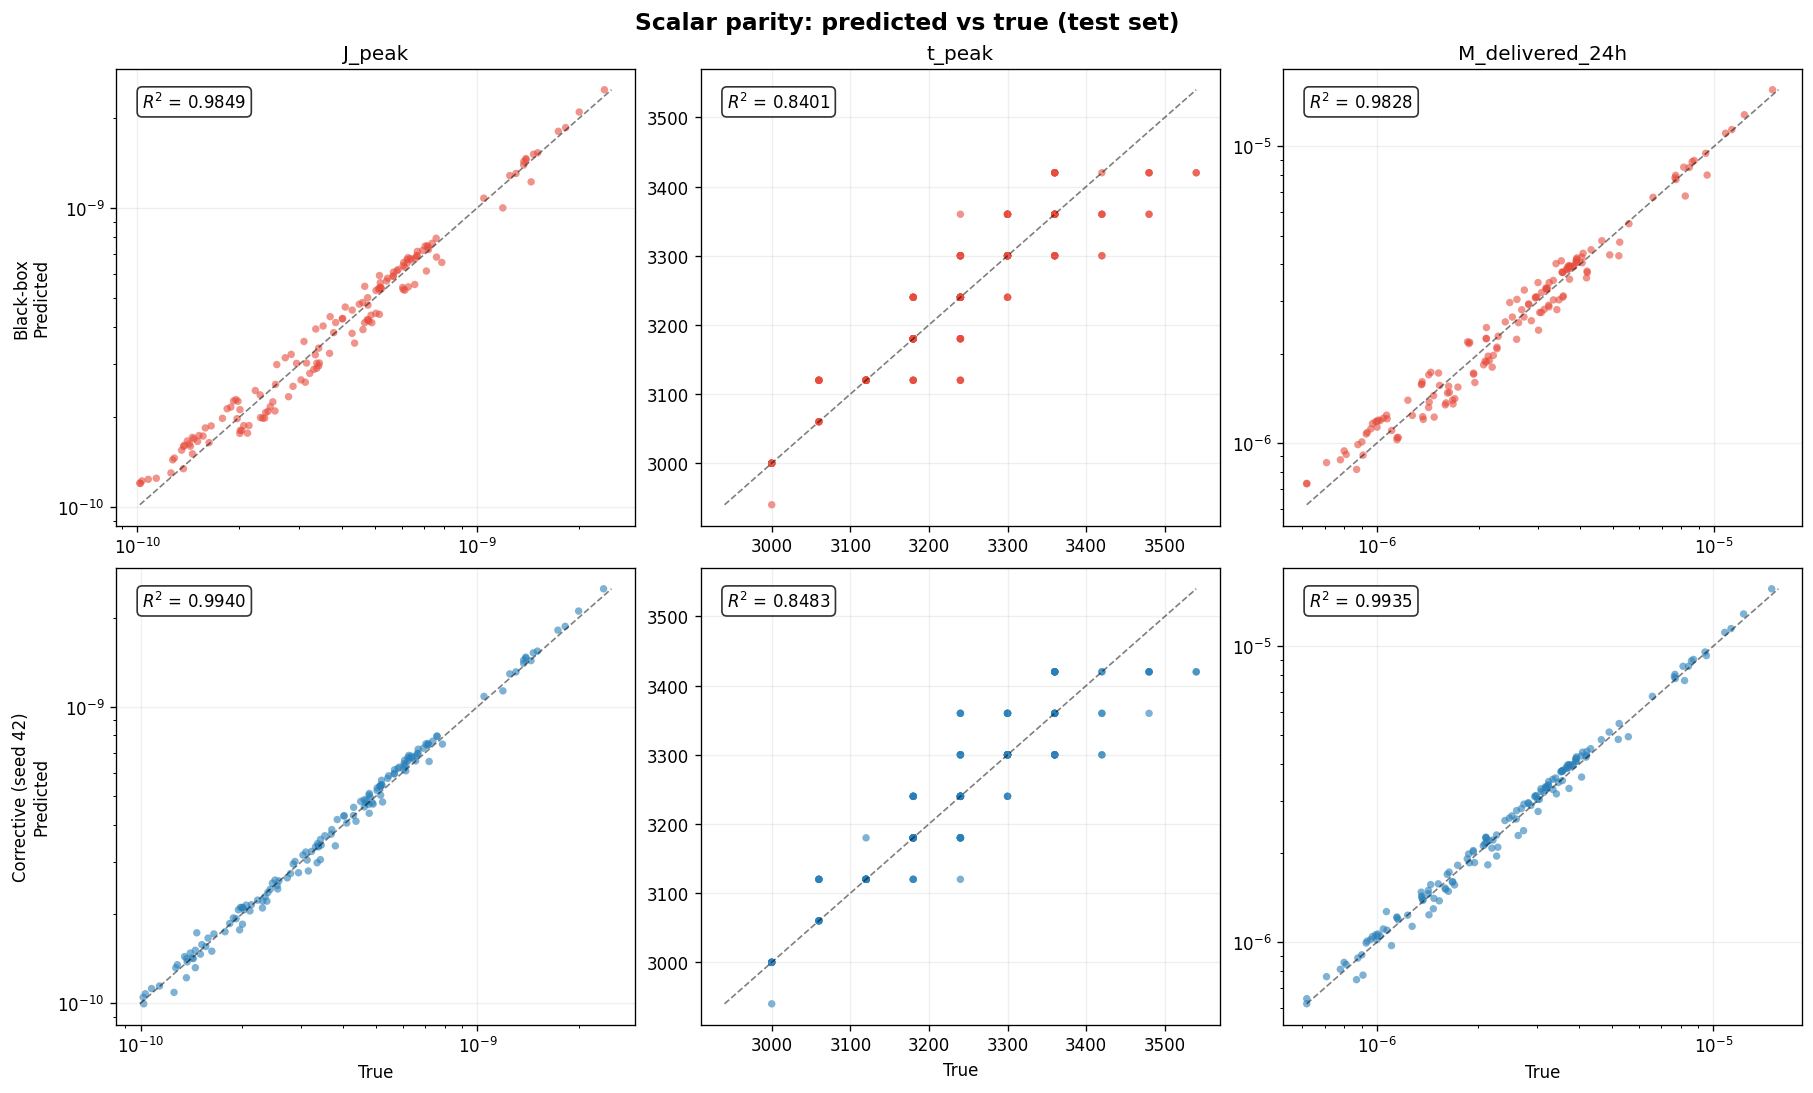

Aggregate scalar metrics for P and J_ss (Ridge predictions):
  P       BB: R2=0.5453, rel_err=0.0%  |  Corrective: R2=0.3041, rel_err=0.0%
  J_ss    BB: R2=0.5338, rel_err=0.0%  |  Corrective: R2=0.3435, rel_err=0.0%


In [18]:
# Load true scalar targets from test set
test_data = np.load('data/processed/ml/test.npz')
y_true_scalar = test_data['y_scalar']  # (150, 5)
target_names = ['P', 'J_ss', 'J_peak', 't_peak', 'M_delivered_24h']
target_idx = {t: i for i, t in enumerate(target_names)}

# Extract predicted scalars from predicted flux curves
def extract_scalars_from_curves(j_pred, t_arr):
    """Derive J_peak, t_peak, M_delivered_24h from predicted flux curves."""
    j_peak = np.max(j_pred, axis=1)
    t_peak = np.array([t_arr[i, np.argmax(j_pred[i])] for i in range(len(j_pred))])
    m_del = np.trapezoid(j_pred, t_arr, axis=1)
    return {'J_peak': j_peak, 't_peak': t_peak, 'M_delivered_24h': m_del}

bb_scalars = extract_scalars_from_curves(bb_pred['j_stageFinal'], bb_pred['t'])
corr_scalars = extract_scalars_from_curves(corr_pred['j_stageFinal'], corr_pred['t'])

# Parity scatter plots for curve-derivable targets
scatter_targets = ['J_peak', 't_peak', 'M_delivered_24h']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
fig.suptitle('Scalar parity: predicted vs true (test set)',
             fontsize=14, fontweight='bold')

for col, tname in enumerate(scatter_targets):
    y_true = y_true_scalar[:, target_idx[tname]]
    use_log = tname in ['J_peak', 'M_delivered_24h']

    for row, (pred, label, colour) in enumerate([
        (bb_scalars[tname], 'Black-box', '#e74c3c'),
        (corr_scalars[tname], 'Corrective (seed 42)', '#2980b9'),
    ]):
        ax = axes[row, col]
        ax.scatter(y_true, pred, s=20, alpha=0.6, color=colour, edgecolors='none')

        # Diagonal reference
        if use_log:
            ax.set_xscale('log')
            ax.set_yscale('log')
        lo = min(y_true.min(), pred.min())
        hi = max(y_true.max(), pred.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5)

        # R-squared
        ss_res = np.sum((y_true - pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        ax.text(0.05, 0.95, f'$R^2$ = {r2:.4f}', transform=ax.transAxes,
                va='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

        if row == 0:
            ax.set_title(tname, fontsize=12)
        if col == 0:
            ax.set_ylabel(f'{label}\nPredicted', fontsize=10)
        if row == 1:
            ax.set_xlabel('True', fontsize=10)
        ax.grid(alpha=0.2)

plt.show()

# Aggregate metrics for P and J_ss (predicted by scalar Ridge, not derivable from curves)
print('Aggregate scalar metrics for P and J_ss (Ridge predictions):')
for tname in ['P', 'J_ss']:
    bb_met = bb['stageFinal']['scalar'][tname]
    corr_met = corr_seeds[42]['metrics']['stageFinal']['scalar'][tname]
    print(f'  {tname:6s}  BB: R2={bb_met["r2"]:.4f}, rel_err={bb_met["relative_error_percent"]:.1f}%  |  '
          f'Corrective: R2={corr_met["r2"]:.4f}, rel_err={corr_met["relative_error_percent"]:.1f}%')


**Breakdown.** Parity plots show scalars derived from predicted flux curves vs ground truth.

- **$J_\text{peak}$ and $M_\text{delivered\_24h}$** typically show the clearest gain from the corrective hybrid.
- **$t_\text{peak}$** is usually similar between models, with small improvements in many runs.
- **$P$ and $J_\text{ss}$** should be interpreted from the printed aggregate metrics (these targets have narrow variance in this regime).

Use this panel for qualitative shape/tightness; use the metric tables for final numeric claims.


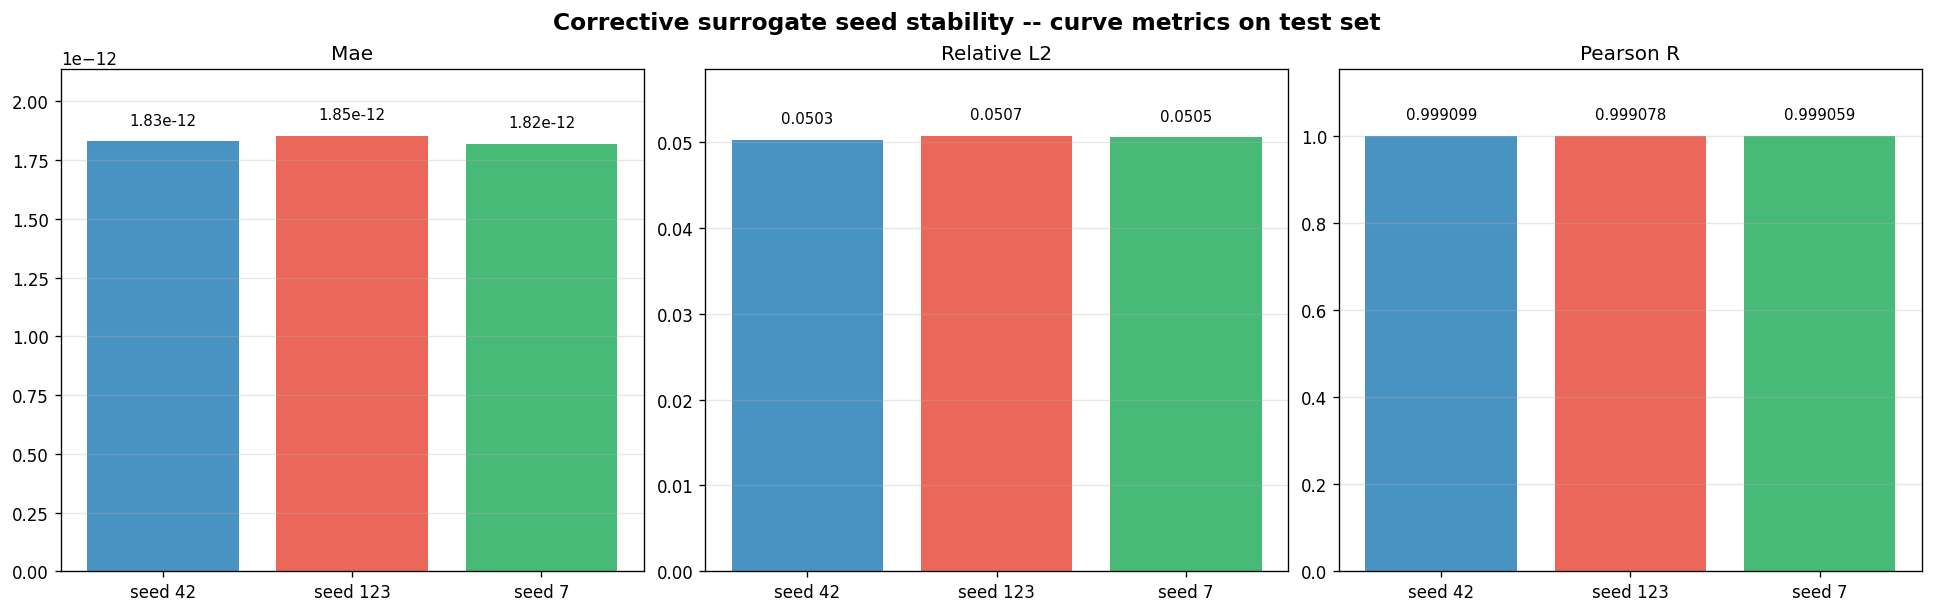

Target                     seed 42        seed 123          seed 7
------------------------------------------------------------------
P                       7.1371e-17      1.1108e-16      7.2778e-17
J_ss                    7.2977e-17      1.1168e-16      7.3571e-17
J_peak                  3.0835e-11      3.0966e-11      3.0845e-11
t_peak                  4.7244e+01      4.6989e+01      4.7244e+01
M_delivered_24h         1.9767e-07      2.0008e-07      1.9953e-07


In [19]:
# Gather curve-level metrics across report seeds
seed_curve_metrics = {}
for seed in seed_order:
    m = corr_seeds[seed]['metrics']['stageFinal']['curve']
    seed_curve_metrics[seed] = m

curve_keys = ['mae', 'relative_l2', 'pearson_r']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Corrective surrogate seed stability -- curve metrics on test set', fontsize=14, fontweight='bold')

for ax, key in zip(axes, curve_keys):
    vals = [seed_curve_metrics[s][key] for s in seed_order]
    bars = ax.bar([f'seed {s}' for s in seed_order], vals,
                  color=[seed_colours[s] for s in seed_order], alpha=0.85)
    ax.set_title(key.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)

    v_min = min(vals) if vals else 0.0
    v_max = max(vals) if vals else 1.0
    span = max(v_max - v_min, 0.0)

    # Honest visual scale: keep bars anchored at zero for fair comparison.
    y_pad = max(0.07 * v_max, 1e-15)
    ax.set_ylim(0.0, v_max + 2.2 * y_pad)

    for bar, val in zip(bars, vals):
        if key == 'mae':
            label_txt = f'{val:.2e}'
        elif key == 'relative_l2':
            label_txt = f'{val:.4f}'
        else:
            label_txt = f'{val:.6f}'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.45 * y_pad,
            label_txt,
            ha='center',
            va='bottom',
            fontsize=9,
            clip_on=False,
        )


plt.show()

# Scalar RMSE table
print(f'{"Target":<18s}', end='')
for seed in seed_order:
    print(f'{"seed " + str(seed):>16s}', end='')
print()
print('-' * (18 + 16 * max(1, len(seed_order))))
for tname in target_names:
    print(f'{tname:<18s}', end='')
    for seed in seed_order:
        rmse = corr_seeds[seed]['summary']['test_scalar_rmse'][tname]
        print(f'{rmse:>16.4e}', end='')
    print()
